In [8]:
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import h3
import pandas as pd
import numpy as np
import os
from pathlib import Path
import geopandas as gpd
import contextily as ctx
import io, zipfile, requests
import shapely

import folium
import mapclassify

In [9]:
# Chicago community area boundaries — download from the city data portal and cache locally
CA_PATH = Path('..') / 'data' / 'chicago_community_areas.gpkg'

if CA_PATH.exists():
    community_areas = gpd.read_file(CA_PATH)
else:
    print('Downloading Chicago community area boundaries...')
    url = 'https://data.cityofchicago.org/resource/igwz-8jzy.geojson?$limit=100'
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    community_areas = gpd.read_file(io.BytesIO(r.content))
    community_areas.to_file(CA_PATH, driver='GPKG')
    print(f'Saved {len(community_areas)} community areas to {CA_PATH}')

community_areas = community_areas.to_crs(epsg=4326)
print(f'Community areas loaded: {len(community_areas)}')

Saved 77 community areas to ../data/chicago_community_areas.gpkg
Community areas loaded: 77


In [10]:
pois_agg = pd.read_csv('../data/chicago_pois_agg.csv')

taxi_trips = pd.read_parquet("../data/taxi_data_processed.parquet")

taxi_trips.head()

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Trip Total,Company,h3_index_pickup,h3_index_dropoff,Pickup Hour,Dropoff Hour
0,a1e30fb944a6fd2598a9c3caf0192121f0e39dea,249d932165de24c10140f979fa81b350183cff7ac63099...,04/30/2026 11:45:00 PM,05/01/2026 12:00:00 AM,261.000,0.40,17031833000,17031833000,28.0,28.0,500.0,Globe Taxi,882664cad7fffff,882664cad7fffff,2026-04-30 23:00:00,2026-05-01
1,07df4fb41ec699a5287f8a4e64726563bae385fc,fed019ef14a3bfeaa5ef5f523be5d8dc28943952aa66a3...,04/30/2026 11:45:00 PM,05/01/2026 12:00:00 AM,240.000,0.90,17031833000,17031081800,28.0,8.0,525.0,Choice Taxi Association Inc,882664cad7fffff,882664c1e5fffff,2026-04-30 23:00:00,2026-05-01
2,5d9e23fa8a4beb9d495f5c4c7c00bf33026b561e,fb1ed566274f6a66dfcddbe4c014bbe87ac3516412dfe6...,04/30/2026 11:45:00 PM,05/01/2026 12:00:00 AM,425.000,1.41,17031833000,17031320400,28.0,32.0,845.0,Sun Taxi,882664cad7fffff,882664c1abfffff,2026-04-30 23:00:00,2026-05-01
3,e6ba74242fb88764fb6cb5e34a7f399b613c1a6b,3278a0dd17ed3de47adf8cf7236bf8f21f29e62c04394b...,04/30/2026 11:45:00 PM,05/01/2026 12:00:00 AM,1.560,16.80,17031980000,17031320400,76.0,32.0,5375.0,Transit Administrative Center Inc,88275934edfffff,882664c1abfffff,2026-04-30 23:00:00,2026-05-01
4,876f1c50d59ac611ff5daca49934a046c951de40,3f365e125eb1d15aae0ae8a4bf53a01191478f26ccf00c...,04/30/2026 11:45:00 PM,05/01/2026 12:00:00 AM,1.297,17.10,17031980000,17031833000,76.0,28.0,4725.0,5 Star Taxi,88275934edfffff,882664cad7fffff,2026-04-30 23:00:00,2026-05-01


In [16]:
# Define aggregations specifically for the Pickups
pickup_aggregations = {
    'Total_Trip_Start': ('Trip ID', 'count'),
    'Unique Taxis': ('Taxi ID', 'nunique'),
    'Avg Trip Seconds': ('Trip Seconds', 'mean'),
    'Avg Trip Miles': ('Trip Miles', 'mean'),
    'Avg Fare': ('Trip Total', 'mean'),
    'Most Common Company': ('Company', lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    'Company Count': ('Company', 'nunique')
}

# Define aggregations specifically for the Dropoffs
dropoff_aggregations = {
    'Total_Trip_End': ('Trip ID', 'count'),
    'Unique Taxis': ('Taxi ID', 'nunique'),
    'Avg Trip Seconds': ('Trip Seconds', 'mean'),
    'Avg Trip Miles': ('Trip Miles', 'mean'),
    'Avg Fare': ('Trip Total', 'mean'),
    'Most Common Company': ('Company', lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    'Company Count': ('Company', 'nunique')
}

# Perform two separate groupbys
agg_pickups = taxi_trips.groupby(
    ['h3_index_pickup', 'Pickup Hour']
).agg(**pickup_aggregations).reset_index()

agg_dropoffs = taxi_trips.groupby(
    ['h3_index_dropoff', 'Dropoff Hour']
).agg(**dropoff_aggregations).reset_index()

In [12]:
agg_pickups.head()

,h3_index_pickup,Pickup Hour,Total_Trip_Start,Unique Taxis,Avg Trip Seconds,Avg Trip Miles,Avg Fare,Most Common Company,Company Count
0,882664191dfffff,2024-03-19 12:00:00,1,1,4.119,37.750,9675.0,Flash Cab,1
1,882664191dfffff,2025-06-18 07:00:00,1,1,2.264,19.710,5871.0,Flash Cab,1
2,882664191dfffff,2025-07-06 12:00:00,1,1,3.929,37.390,10303.0,Flash Cab,1
3,882664191dfffff,2025-08-30 12:00:00,2,1,102.000,0.295,412.5,Flash Cab,1
4,8826641937fffff,2025-05-20 11:00:00,1,1,1.080,11.200,2950.0,Taxi Affiliation Services,1


In [18]:
def get_hexagon_grid(data, h3_col='h3_index'):
    """
    Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source.

    Parameters
    ----------
    data : pd.DataFrame or pd.Series
        Source data. If DataFrame, all columns are kept in the output.
        If Series, the output has only 'h3_index' and 'geometry'.
    h3_col : str
        Column in `data` containing H3 cell IDs (ignored when data is a Series).

    Returns
    -------
    GeoDataFrame with all original columns plus 'geometry', CRS EPSG:4326.
    """
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        h3_list = list(data)
        df = pd.DataFrame({'h3_index': h3_list})
    else:
        h3_list = list(data[h3_col])
        df = data.reset_index(drop=True)

    geometries = [_to_polygon(cell) for cell in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs='EPSG:4326')


def create_choropleth_plot(
    gdf,
    value_col='poi_count',
    title='POI count per H3 hexagon',
    boundaries=None,
    cmap='YlOrRd',
    figsize=(6, 8),
    k=7,
):
    """
    Create a static matplotlib choropleth of hexagon values with Chicago basemap.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must contain 'geometry' and `value_col`. CRS EPSG:4326.
    value_col : str
        Column used to colour hexagons.
    title : str
        Figure title.
    boundaries : GeoDataFrame or None
        Community area outlines to overlay. Defaults to the global `community_areas`.
    cmap : str
        Matplotlib colour map name.
    figsize : tuple
        Figure size in inches.
    k : int
        Number of quantile classes for the colour scheme.

    Returns
    -------
    fig, ax
    """
    if boundaries is None:
        boundaries = community_areas

    fig, ax = plt.subplots(figsize=figsize)

    gdf_web = gdf.to_crs(epsg=3857)
    gdf_web.plot(
        ax=ax,
        column=value_col,
        cmap=cmap,
        scheme='quantiles',
        k=k,
        edgecolor='none',
        alpha=0.8,
        legend=True,
        zorder=1,
        legend_kwds=dict(
            title=value_col.replace('_', ' ').title(),
            loc='lower right',
            fontsize=8,
            title_fontsize=9,
        ),
        missing_kwds=dict(color='lightgrey', label='No data'),
    )

    # Basemap underneath everything
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)

    # Community area outlines drawn last so they sit on top of basemap and hexagons
    boundaries.to_crs(epsg=3857).boundary.plot(
        ax=ax, color='#222', linewidth=1.0, alpha=0.9, zorder=3,
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    return fig, ax

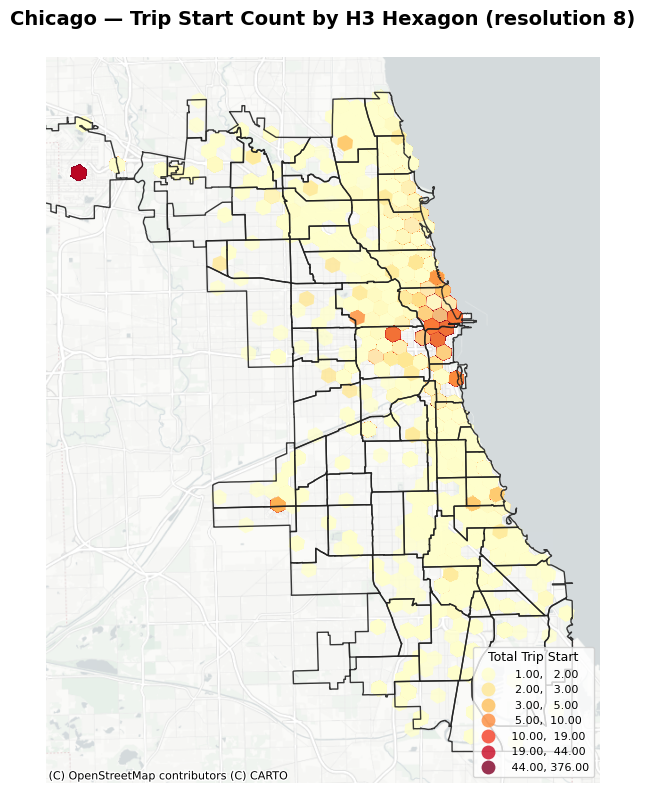

In [19]:
hex_gdf = get_hexagon_grid(agg_pickups, h3_col='h3_index_pickup')

fig, ax = create_choropleth_plot(
    hex_gdf,
    value_col='Total_Trip_Start',
    title='Chicago — Trip Start Count by H3 Hexagon (resolution 8)',
)
plt.show()

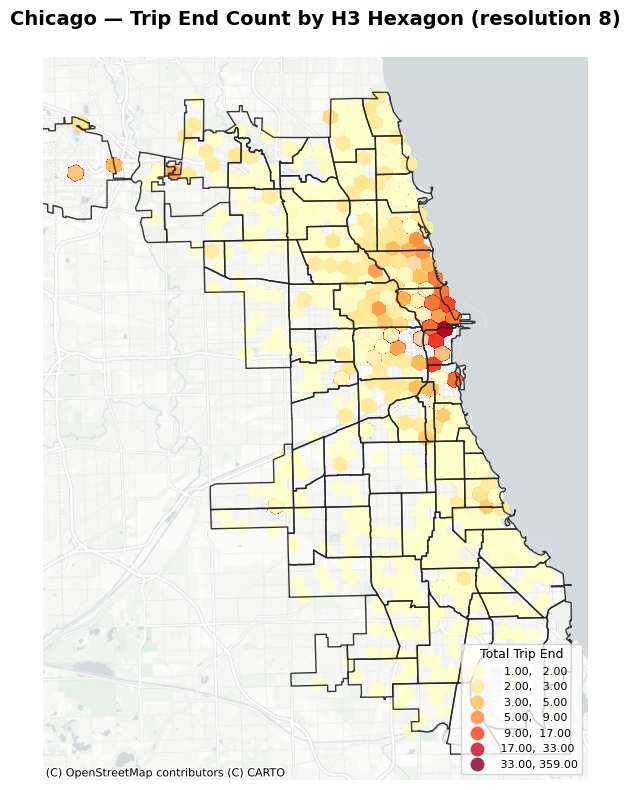

In [20]:
hex_gdf = get_hexagon_grid(agg_dropoffs, h3_col='h3_index_dropoff')

fig, ax = create_choropleth_plot(
    hex_gdf,
    value_col='Total_Trip_End',
    title='Chicago — Trip End Count by H3 Hexagon (resolution 8)',
)
plt.show()

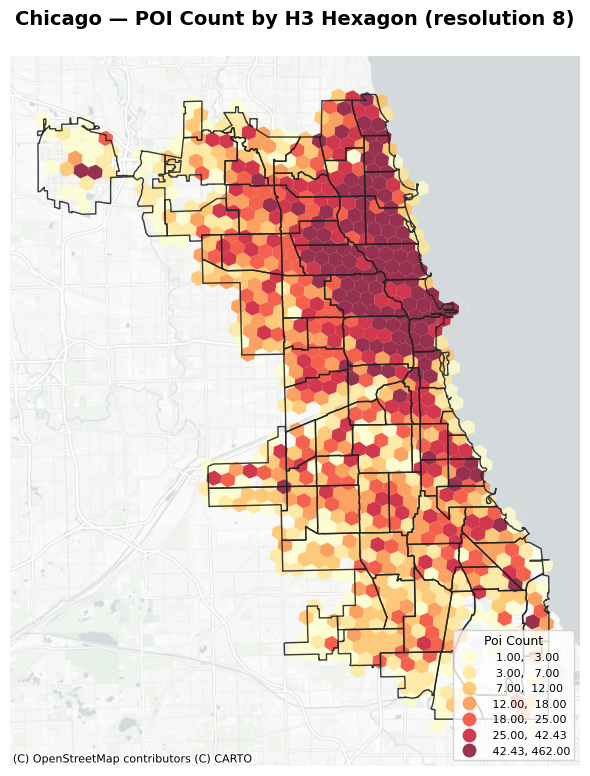

In [21]:
hex_gdf = get_hexagon_grid(pois_agg, h3_col='h3_index')

fig, ax = create_choropleth_plot(
    hex_gdf,
    value_col='poi_count',
    title='Chicago — POI Count by H3 Hexagon (resolution 8)',
)
plt.show()